**Librerías, estilo y utilidades**

In [8]:

# -*- coding: utf-8 -*-
# ============================================================
# CELDA 1. LIBRERÍAS, CONFIGURACIÓN Y UTILIDADES
# ============================================================
import pandas as pd
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def moneda(x):
    try:
        return f"${x:,.2f}"
    except Exception:
        return str(x)

def encabezado(md_text):
    display(Markdown(md_text))


## **Ingesta desde la “API” (raw GitHub) y aplanado del JSON**

In [9]:

# ============================================================
# CELDA 2. EXTRACCIÓN DESDE API (RAW GITHUB) + NORMALIZACIÓN
# ============================================================

# URL raw del JSON (API del challenge)
URL_JSON = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Extraer desde la web (requests) y cargar como JSON
resp = requests.get(URL_JSON, timeout=30)
resp.raise_for_status()
data_json = resp.json()   # lista de dicts anidados

# Aplanar JSON -> DataFrame tabular
df_raw = pd.json_normalize(data_json)

encabezado("### Vista inicial del dataset (aplanado)")
display(df_raw.head(3))
print(f"Dimensiones iniciales: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print("Columnas:", list(df_raw.columns))


### Vista inicial del dataset (aplanado)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


Dimensiones iniciales: 7267 filas × 21 columnas
Columnas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


**Diccionario de datos (consulta directa del repo)**

In [10]:

# ============================================================
# CELDA 3. CONSULTA DEL DICCIONARIO DE DATOS
# ============================================================

URL_DICC = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md"

try:
    dicc_md = requests.get(URL_DICC, timeout=30).text
    encabezado("### Extracto del diccionario de datos")
    # mostramos solo las primeras ~80 líneas para no saturar
    preview = "\n".join(dicc_md.splitlines()[:80])
    print(preview)
    print("\n(Enlace completo):", URL_DICC)
except Exception as e:
    print("No se pudo descargar el diccionario. Revise la URL o conexión.", e)


### Extracto del diccionario de datos

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

**Exploración de columnas, dtypes y estructura**

In [11]:

# ============================================================
# CELDA 4. EDA BÁSICO: COLUMNAS Y TIPOS
# ============================================================

encabezado("### Tipos de datos y no-nulos por columna")
df_raw.info()

encabezado("### Conteo de valores únicos por columna (muestra)")
for col in df_raw.columns:
    nun = df_raw[col].nunique(dropna=False)
    if nun <= 20:  # evitar imprimir columnas con demasiados únicos
        print(f"- {col}: {nun} valores →", df_raw[col].unique())


### Tipos de datos y no-nulos por columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

### Conteo de valores únicos por columna (muestra)

- Churn: 3 valores → ['No' 'Yes' '']
- customer.gender: 2 valores → ['Female' 'Male']
- customer.SeniorCitizen: 2 valores → [0 1]
- customer.Partner: 2 valores → ['Yes' 'No']
- customer.Dependents: 2 valores → ['Yes' 'No']
- phone.PhoneService: 2 valores → ['Yes' 'No']
- phone.MultipleLines: 3 valores → ['No' 'Yes' 'No phone service']
- internet.InternetService: 3 valores → ['DSL' 'Fiber optic' 'No']
- internet.OnlineSecurity: 3 valores → ['No' 'Yes' 'No internet service']
- internet.OnlineBackup: 3 valores → ['Yes' 'No' 'No internet service']
- internet.DeviceProtection: 3 valores → ['No' 'Yes' 'No internet service']
- internet.TechSupport: 3 valores → ['Yes' 'No' 'No internet service']
- internet.StreamingTV: 3 valores → ['Yes' 'No' 'No internet service']
- internet.StreamingMovies: 3 valores → ['No' 'Yes' 'No internet service']
- account.Contract: 3 valores → ['One year' 'Month-to-month' 'Two year']
- account.PaperlessBilling: 2 valores → ['Yes' 'No']
- account.PaymentMethod: 4 valo

**Selección de columnas relevantes y chequeos de calidad**

A partir de experiencias previas en este challenge, tras el aplanado suelen verse columnas equivalentes a:
customer.gender, customer.SeniorCitizen, customer.Partner, customer.Dependents, customer.tenure, phone.PhoneService, phone.MultipleLines, internet.InternetService, etc....

In [12]:

# ============================================================
# CELDA 5. SELECCIÓN DE COLUMNAS RELEVANTES + QA
# ============================================================

# Mapeo de columnas esperadas (con fallback si alguna no existe)
colmap = {
    "customerID": "customerID",
    "Churn": "Churn",
    "customer.gender": "gender",
    "customer.SeniorCitizen": "senior",
    "customer.Partner": "partner",
    "customer.Dependents": "dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "phone_service",
    "phone.MultipleLines": "multiple_lines",
    "internet.InternetService": "internet_service",
    "internet.OnlineSecurity": "online_security",
    "internet.OnlineBackup": "online_backup",
    "internet.DeviceProtection": "device_protection",
    "internet.TechSupport": "tech_support",
    "internet.StreamingTV": "streaming_tv",
    "internet.StreamingMovies": "streaming_movies",
    "account.Contract": "contract",
    "account.PaperlessBilling": "paperless_billing",
    "account.PaymentMethod": "payment_method",
    "account.Charges.Monthly": "charges_monthly",
    "account.Charges.Total": "charges_total"
}

# Tomamos solo las columnas presentes
present_cols = [c for c in colmap.keys() if c in df_raw.columns]
df = df_raw[present_cols].copy()
df.rename(columns=colmap, inplace=True)

encabezado("### Columnas escogidas para churn")
print(list(df.columns))

# CHEQUEOS DE CALIDAD
encabezado("### Chequeos de calidad de datos")
print("Duplicados exactos:", df.duplicated(keep=False).sum())
print("\nNulos por columna:\n", df.isna().sum().sort_values(ascending=False))

# Revisar strings en blanco (p.ej.: 'Churn' puede tener '' en algunos forks/notebooks)
for col in df.select_dtypes(include='object').columns:
    blancos = (df[col].astype(str).str.strip() == "").sum()
    if blancos > 0:
        print(f"- Valores en blanco en '{col}': {blancos}")


### Columnas escogidas para churn

['customerID', 'Churn', 'gender', 'senior', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'charges_monthly', 'charges_total']


### Chequeos de calidad de datos

Duplicados exactos: 0

Nulos por columna:
 customerID           0
Churn                0
gender               0
senior               0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
charges_monthly      0
charges_total        0
dtype: int64
- Valores en blanco en 'Churn': 224
- Valores en blanco en 'charges_total': 11


**Limpieza y correcciones (formato, categorías, nulos)**

In [13]:

# ============================================================
# CELDA 6. LIMPIEZA Y CORRECCIONES
# ============================================================

# 1) Estandarizar espacios y capitalización en categóricas
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# 2) Normalizar 'Churn': reemplazar blancos por 'No' (criterio conservador)
df["Churn"] = df["Churn"].replace({"": "No"})

# 3) Convertir cargos a numérico (mensual y total)
num_cols = []
if "charges_monthly" in df.columns:
    df["charges_monthly"] = pd.to_numeric(df["charges_monthly"], errors="coerce")
    num_cols.append("charges_monthly")
if "charges_total" in df.columns:
    df["charges_total"] = pd.to_numeric(df["charges_total"], errors="coerce")
    num_cols.append("charges_total")

# 4) Estandarizar categorías tipo "No internet service"/"No phone service"→"No"
reemplazos_no = {
    "No internet service": "No",
    "No phone service": "No",
    "No Internet service": "No",
    "No internet": "No"
}
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in ["customerID"]]
for c in cat_cols:
    df[c] = df[c].replace(reemplazos_no)

# 5) Convertir SeniorCitizen a 0/1 si viene como bool/obj
if "senior" in df.columns:
    df["senior"] = pd.to_numeric(df["senior"], errors="coerce").fillna(0).astype(int)

# 6) Reconstruir 'charges_total' (si falta) usando tenure * charges_monthly como criterio
if {"charges_total", "charges_monthly", "tenure"}.issubset(df.columns):
    mask_miss_total = df["charges_total"].isna() & df["tenure"].notna() & df["charges_monthly"].notna()
    df.loc[mask_miss_total, "charges_total"] = df.loc[mask_miss_total, "charges_monthly"] * df.loc[mask_miss_total, "tenure"]

# 7) Drop duplicados por customerID (quedarnos con el último)
if "customerID" in df.columns:
    antes = len(df)
    df = df.drop_duplicates(subset=["customerID"], keep="last")
    print(f"Registros removidos por duplicado de customerID: {antes - len(df)}")

# 8) Último chequeo de nulos
encabezado("### Nulos post-limpieza")
print(df.isna().sum().sort_values(ascending=False))


Registros removidos por duplicado de customerID: 0


### Nulos post-limpieza

customerID           0
Churn                0
gender               0
senior               0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
charges_monthly      0
charges_total        0
dtype: int64


**Nueva métrica: Cuentas_Diarias**

Calculamos el promedio diario a partir de la facturación mensual. Usamos 30.44 días (promedio anual/12) para una aproximación estable.

In [14]:

#=========================================================
# CELDA 7. FEATURE ENGINEERING: CUENTAS_DIARIAS
# ============================================================

if "charges_monthly" in df.columns:
    df["Cuentas_Diarias"] = (df["charges_monthly"] / 30.44).round(2)
else:
    df["Cuentas_Diarias"] = np.nan

encabezado("### Vista con Cuentas_Diarias")
display(df[["customerID","charges_monthly","Cuentas_Diarias","Churn"]].head(5))


### Vista con Cuentas_Diarias

,customerID,charges_monthly,Cuentas_Diarias,Churn
0,0002-ORFBO,65.6,2.16,No
1,0003-MKNFE,59.9,1.97,No
2,0004-TLHLJ,73.9,2.43,Yes
3,0011-IGKFF,98.0,3.22,Yes
4,0013-EXCHZ,83.9,2.76,Yes


**Estandarización y renombrado al español**

In [15]:

# ============================================================
# CELDA 8. ESTANDARIZACIÓN OPCIONAL (Sí/No→1/0) Y RENOMBRES
# ============================================================

df_std = df.copy()

# Mapear binarios Sí/No a 1/0 en columnas candidatas
map_bin = {"Yes":1, "No":0, "Sí":1, "Si":1, "No ":0}
binarias = [c for c in df_std.columns if df_std[c].dtype == 'object' and set(df_std[c].unique()) <= set(map_bin.keys())]
for c in binarias:
    df_std[c] = df_std[c].map(map_bin).astype("float")

# Churn binario
df_std["churn_bin"] = df_std["Churn"].map({"Yes":1, "No":0}).fillna(0).astype(int)

# Renombrado “amigable” (puedes ajustar a tu preferencia)
rename_es = {
    "gender":"Genero",
    "senior":"Adulto_Mayor",
    "partner":"Pareja",
    "dependents":"Dependientes",
    "tenure":"Meses_Cliente",
    "phone_service":"Telefono",
    "multiple_lines":"Lineas_Multiples",
    "internet_service":"Internet",
    "online_security":"Seguridad_Online",
    "online_backup":"Backup_Online",
    "device_protection":"Proteccion_Dispositivo",
    "tech_support":"Soporte_Tecnico",
    "streaming_tv":"Streaming_TV",
    "streaming_movies":"Streaming_Peliculas",
    "contract":"Contrato",
    "paperless_billing":"Factura_Digital",
    "payment_method":"Metodo_Pago",
    "charges_monthly":"Cargos_Mensuales",
    "charges_total":"Cargos_Totales",
    "Cuentas_Diarias":"Cuentas_Diarias"
}
df_std.rename(columns=rename_es, inplace=True)

encabezado("### DataFrame estandarizado (preview)")
display(df_std.head(3))


### DataFrame estandarizado (preview)

,customerID,Churn,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Cliente,Telefono,Lineas_Multiples,Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,churn_bin
0,0002-ORFBO,0.0,Female,0,1.0,1.0,9,1.0,0.0,DSL,...,1.0,1.0,0.0,One year,1.0,Mailed check,65.6,593.30,2.16,0
1,0003-MKNFE,0.0,Male,0,0.0,0.0,9,1.0,1.0,DSL,...,0.0,0.0,1.0,Month-to-month,0.0,Mailed check,59.9,542.40,1.97,0
2,0004-TLHLJ,1.0,Male,0,0.0,0.0,4,1.0,0.0,Fiber optic,...,0.0,0.0,0.0,Month-to-month,1.0,Electronic check,73.9,280.85,2.43,0


**Análisis descriptivo (general y por churn)
Python**

In [16]:

# ============================================================
# CELDA 9. ANÁLISIS DESCRIPTIVO
# ============================================================

num_cols = [c for c in df_std.columns if pd.api.types.is_numeric_dtype(df_std[c]) and c not in [ "churn_bin" ]]

encabezado("### Descriptivo — numéricas (global)")
display(df_std[num_cols].describe().T)

if "churn_bin" in df_std.columns:
    encabezado("### Descriptivo — numéricas por Churn")
    display(df_std.groupby("churn_bin")[num_cols].agg(["mean","median","std","min","max","count"]))


### Descriptivo — numéricas (global)

,count,mean,std,min,25%,50%,75%,max
Churn,7267.0,0.257190,0.437115,0.00,0.000,0.00,1.000,1.00
Adulto_Mayor,7267.0,0.162653,0.369074,0.00,0.000,0.00,0.000,1.00
Pareja,7267.0,0.484106,0.499782,0.00,0.000,0.00,1.000,1.00
Dependientes,7267.0,0.300124,0.458343,0.00,0.000,0.00,1.000,1.00
Meses_Cliente,7267.0,32.346498,24.571773,0.00,9.000,29.00,55.000,72.00
Telefono,7267.0,0.902711,0.296371,0.00,1.000,1.00,1.000,1.00
Lineas_Multiples,7267.0,0.421770,0.493876,0.00,0.000,0.00,1.000,1.00
Seguridad_Online,7267.0,0.285950,0.451897,0.00,0.000,0.00,1.000,1.00
Backup_Online,7267.0,0.344571,0.475261,0.00,0.000,0.00,1.000,1.00
Proteccion_Dispositivo,7267.0,0.342782,0.474672,0.00,0.000,0.00,1.000,1.00


### Descriptivo — numéricas por Churn

Churn                                  Adulto_Mayor         \
              mean median       std  min  max count         mean median   
churn_bin                                                                 
0          0.25719    0.0  0.437115  0.0  1.0  7267     0.162653    0.0   

                         ... Cargos_Totales                     \
                std min  ...            std  min     max count   
churn_bin                ...                                     
0          0.369074   0  ...    2268.648587  0.0  8684.8  7267   

          Cuentas_Diarias                                   
                     mean median       std  min  max count  
churn_bin                                                   
0                2.126155   2.31  0.989744  0.6  3.9  7267  

[1 rows x 102 columns]

**Distribución de Evasión (Churn)**

### Distribución de Churn — tasa global: 0.00%

/tmp/ipykernel_322/3589657063.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_std, x="churn_bin", palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/3589657063.py:11: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(data=df_std, x="churn_bin", palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/3589657063.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No Churn (0)","Churn (1)"])


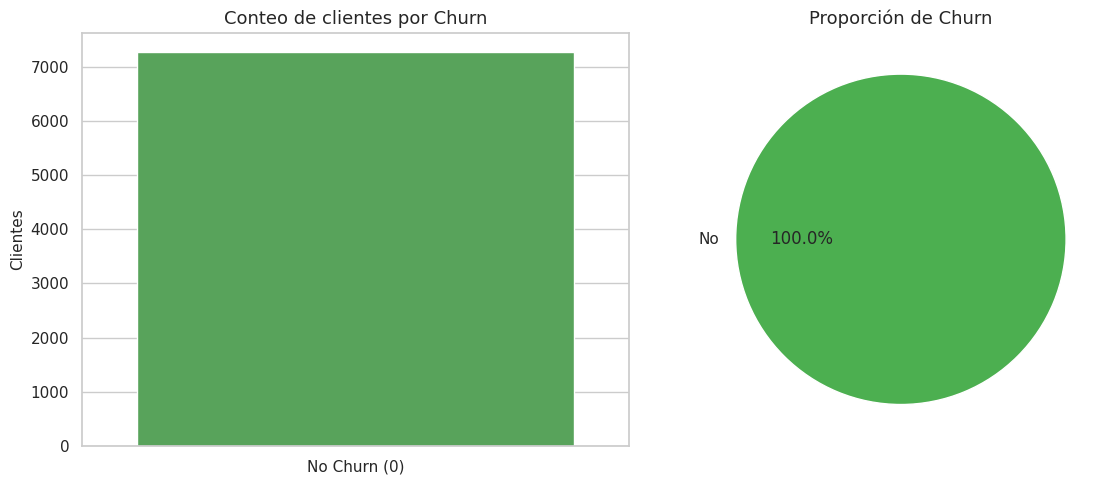

In [17]:

# ============================================================
# CELDA 10. DISTRIBUCIÓN DE CHURN
# ============================================================

if "churn_bin" in df_std.columns:
    tasa_churn = df_std["churn_bin"].mean()
    encabezado(f"### Distribución de Churn — tasa global: {tasa_churn:.2%}")

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    # Conteo
    sns.countplot(data=df_std, x="churn_bin", palette=["#4CAF50","#E53935"], ax=ax[0])
    ax[0].set_xticklabels(["No Churn (0)","Churn (1)"])
    ax[0].set_title("Conteo de clientes por Churn")
    ax[0].set_xlabel("")
    ax[0].set_ylabel("Clientes")
    # Pie
    df_std["churn_bin"].value_counts().plot.pie(autopct="%1.1f%%", labels=["No","Sí"], colors=["#4CAF50","#E53935"], ax=ax[1])
    ax[1].set_ylabel("")
    ax[1].set_title("Proporción de Churn")
    plt.tight_layout()
    plt.show()


**Churn por variables categóricas**

#### Genero: tasa de churn por categoría

,Clientes,Tasa_Churn
Genero,,
Female,3592,0.0
Male,3675,0.0


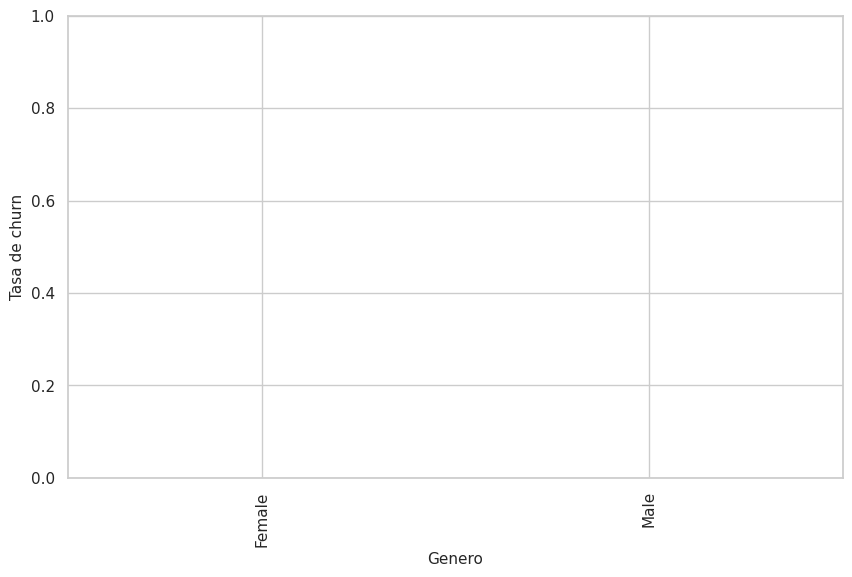

#### Contrato: tasa de churn por categoría

,Clientes,Tasa_Churn
Contrato,,
Month-to-month,4005,0.0
One year,1519,0.0
Two year,1743,0.0


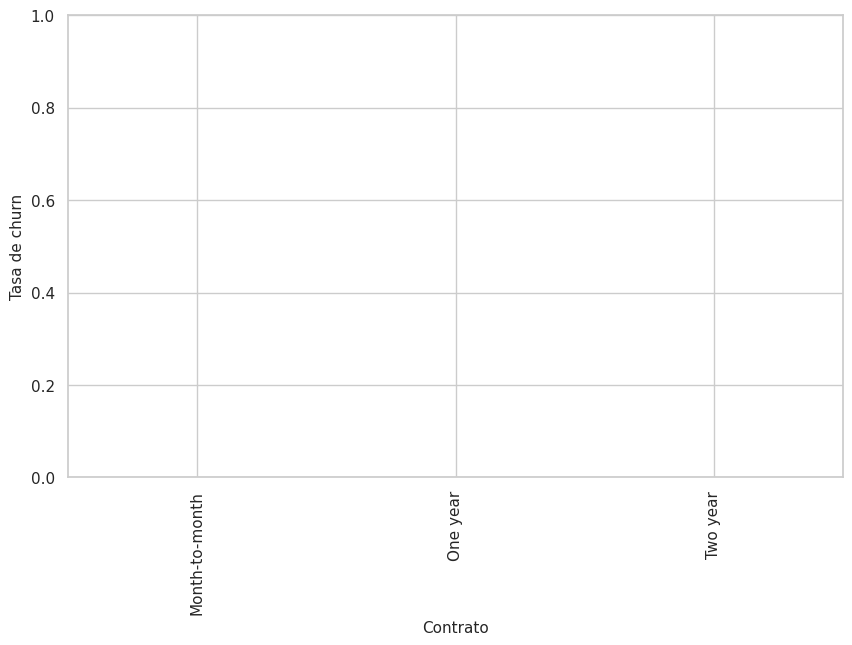

#### Metodo_Pago: tasa de churn por categoría

,Clientes,Tasa_Churn
Metodo_Pago,,
Bank transfer (automatic),1589,0.0
Credit card (automatic),1568,0.0
Electronic check,2445,0.0
Mailed check,1665,0.0


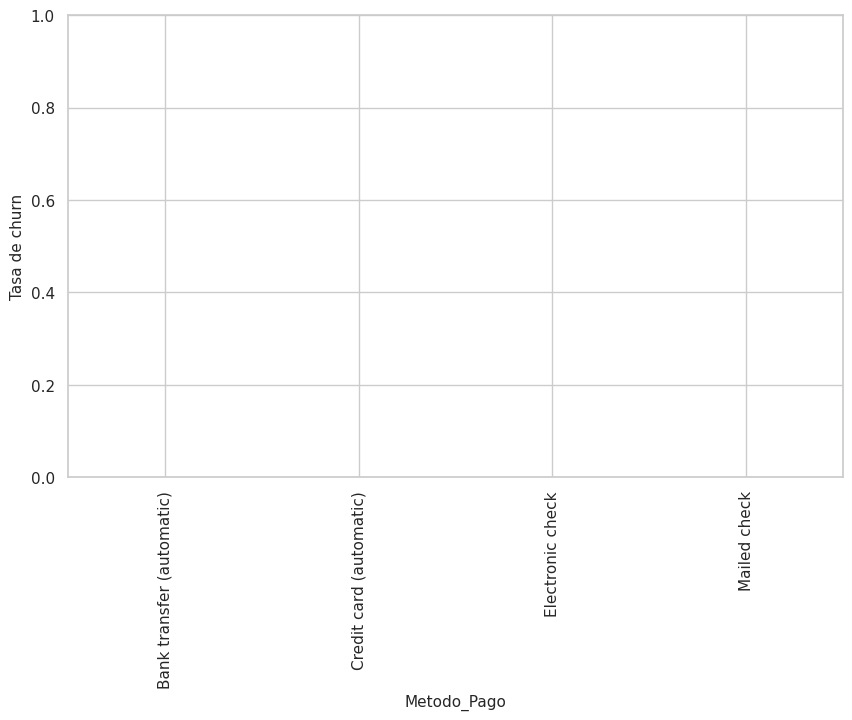

#### Internet: tasa de churn por categoría

,Clientes,Tasa_Churn
Internet,,
DSL,2488,0.0
Fiber optic,3198,0.0
No,1581,0.0


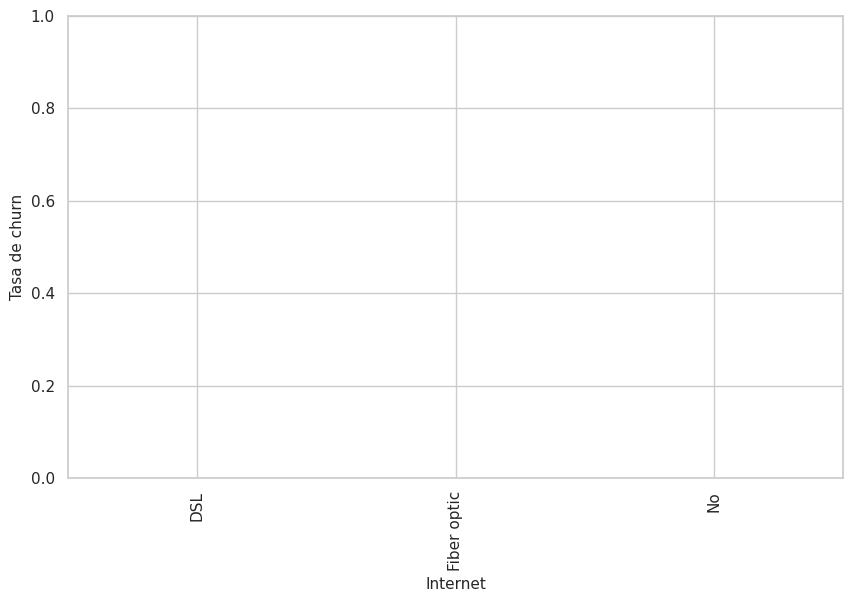

#### Telefono: tasa de churn por categoría

,Clientes,Tasa_Churn
Telefono,,
0.0,707,0.0
1.0,6560,0.0


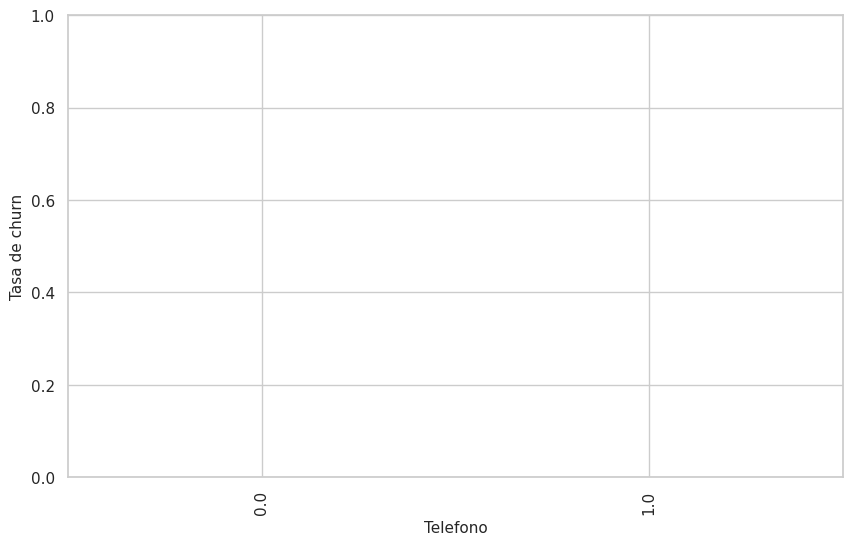

#### Factura_Digital: tasa de churn por categoría

,Clientes,Tasa_Churn
Factura_Digital,,
0.0,2956,0.0
1.0,4311,0.0


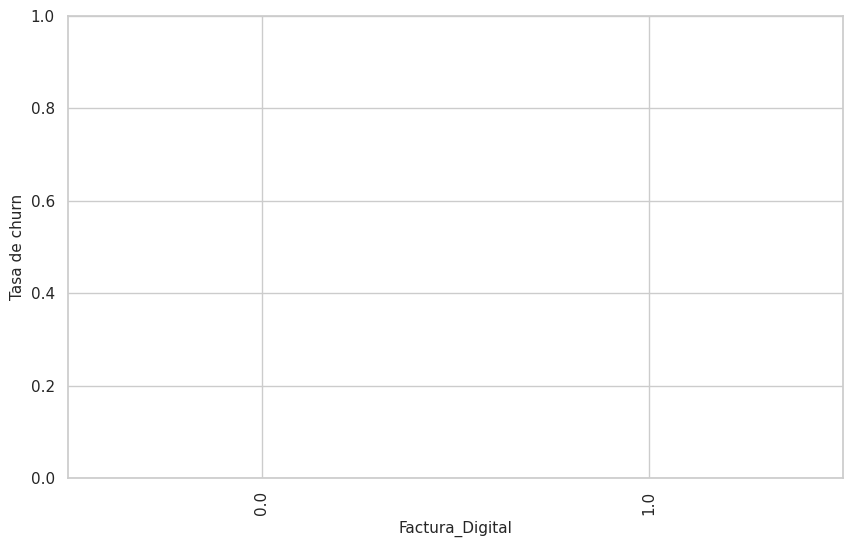

#### Seguridad_Online: tasa de churn por categoría

,Clientes,Tasa_Churn
Seguridad_Online,,
0.0,5189,0.0
1.0,2078,0.0


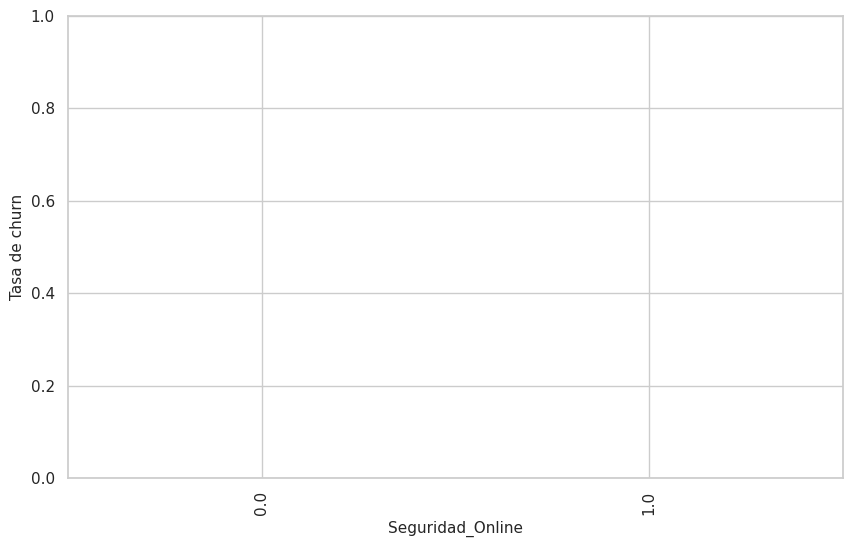

#### Soporte_Tecnico: tasa de churn por categoría

,Clientes,Tasa_Churn
Soporte_Tecnico,,
0.0,5163,0.0
1.0,2104,0.0


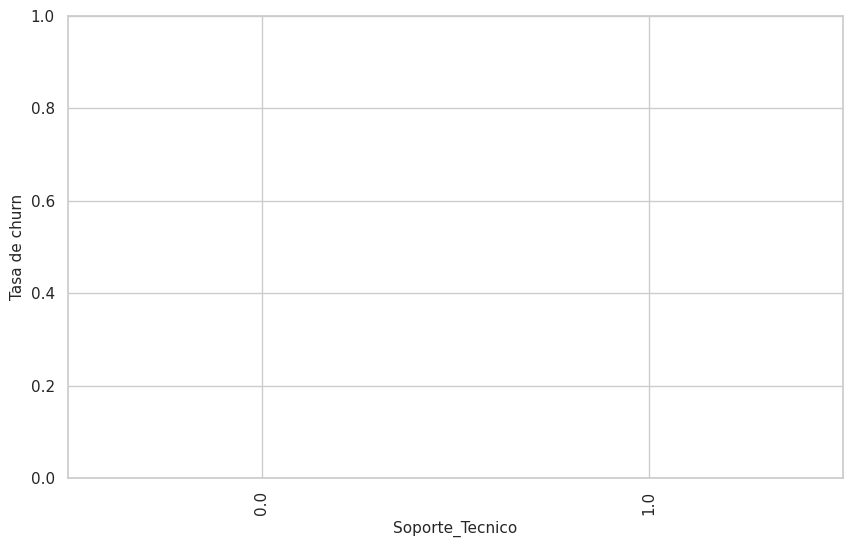

In [18]:

# ============================================================
# CELDA 11. CHURN POR VARIABLES CATEGÓRICAS
# ============================================================

def churn_rate_por_categoria(df_in, var_cat, target="churn_bin", top_n=12):
    tmp = (df_in
           .groupby(var_cat, dropna=False)[target]
           .agg(["count","mean"])
           .rename(columns={"count":"Clientes","mean":"Tasa_Churn"})
           .sort_values("Tasa_Churn", ascending=False))
    if len(tmp) > top_n:
        tmp = tmp.head(top_n)
    return tmp

candidatas_cat = [
    "Genero","Contrato","Metodo_Pago","Internet","Telefono",
    "Factura_Digital","Seguridad_Online","Soporte_Tecnico"
]
candidatas_cat = [c for c in candidatas_cat if c in df_std.columns]

for col in candidatas_cat:
    encabezado(f"#### {col}: tasa de churn por categoría")
    tmp = churn_rate_por_categoria(df_std, col)
    display(tmp)
    # gráfico
    ax = tmp["Tasa_Churn"].plot(kind="bar", color="#1E88E5")
    ax.set_ylabel("Tasa de churn")
    ax.set_xlabel(col)
    plt.ylim(0, 1)
    plt.show()


 **Churn vs variables numéricas (distribuciones/boxplots)**

#### Cargos_Mensuales — distribución por churn

/tmp/ipykernel_322/2607162145.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.kdeplot(data=df_std, x=c, hue="churn_bin", fill=True, common_norm=False, palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/2607162145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["No Churn (0)","Churn (1)"])


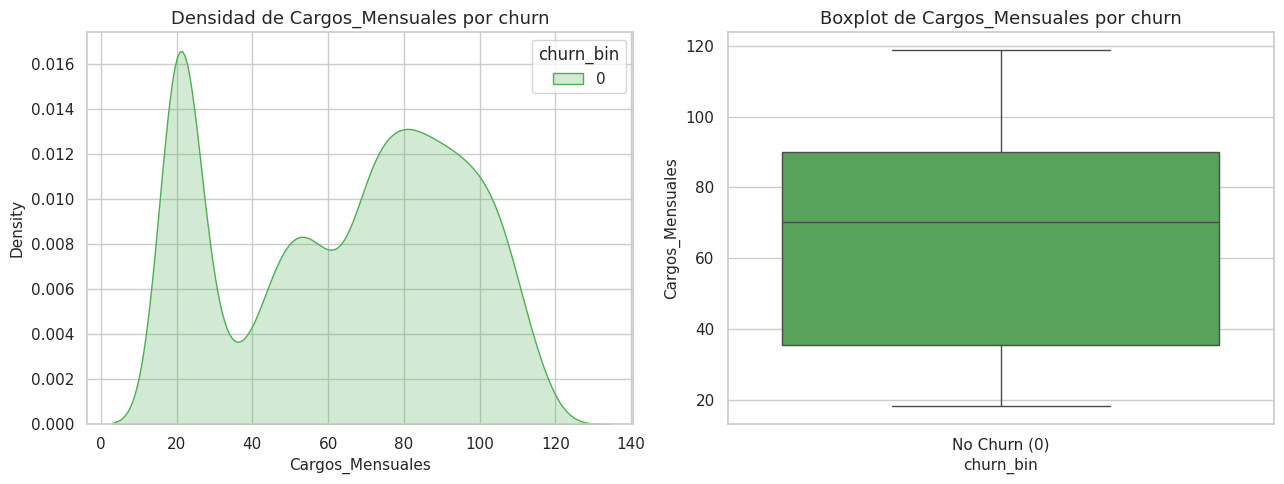

#### Cargos_Totales — distribución por churn

/tmp/ipykernel_322/2607162145.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.kdeplot(data=df_std, x=c, hue="churn_bin", fill=True, common_norm=False, palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/2607162145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["No Churn (0)","Churn (1)"])


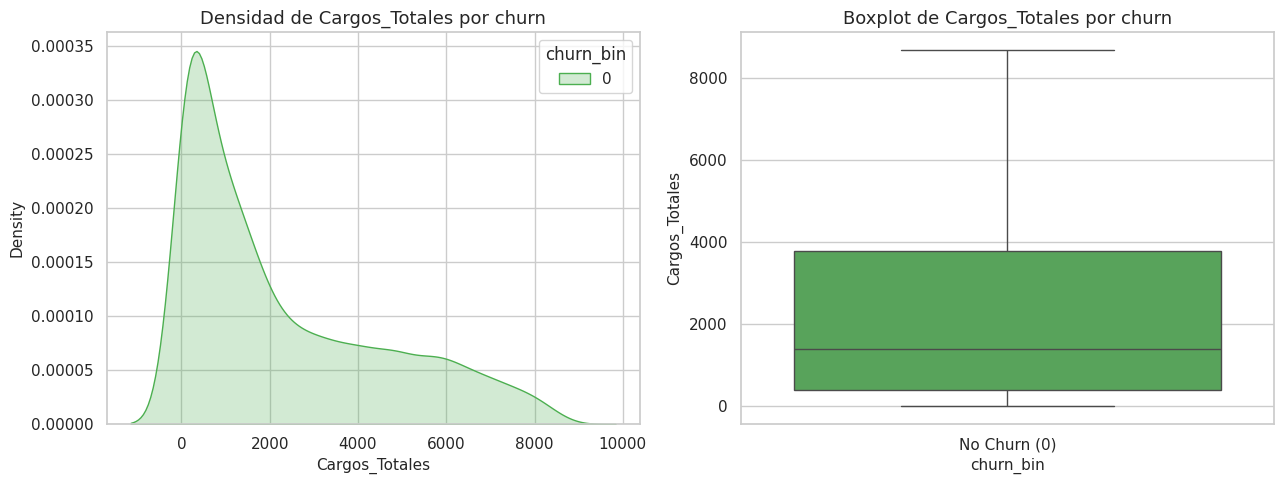

#### Meses_Cliente — distribución por churn

/tmp/ipykernel_322/2607162145.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.kdeplot(data=df_std, x=c, hue="churn_bin", fill=True, common_norm=False, palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/2607162145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["No Churn (0)","Churn (1)"])


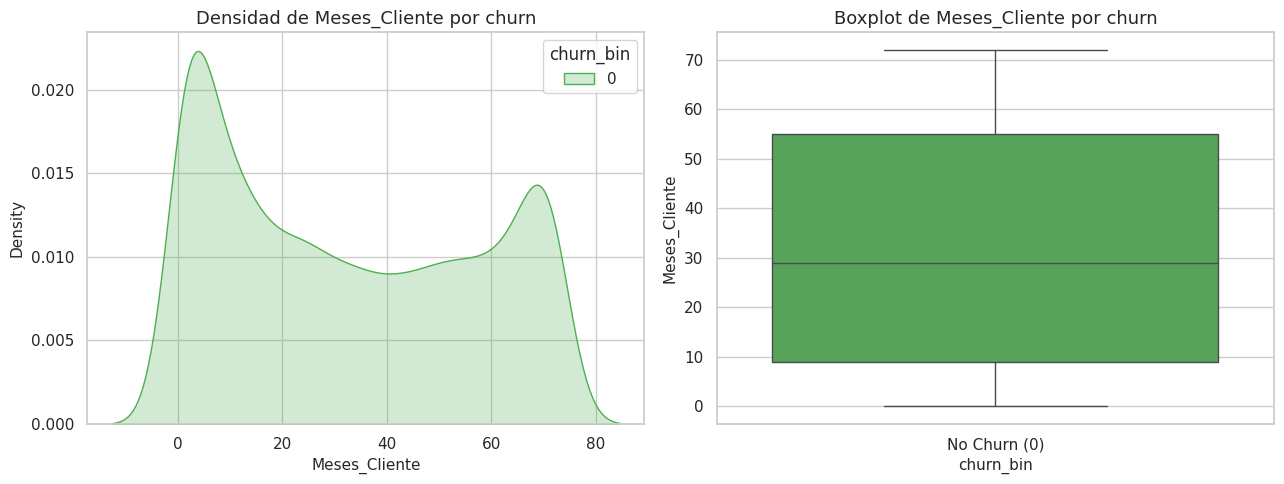

#### Cuentas_Diarias — distribución por churn

/tmp/ipykernel_322/2607162145.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.kdeplot(data=df_std, x=c, hue="churn_bin", fill=True, common_norm=False, palette=["#4CAF50","#E53935"], ax=ax[0])
/tmp/ipykernel_322/2607162145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
/tmp/ipykernel_322/2607162145.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["No Churn (0)","Churn (1)"])


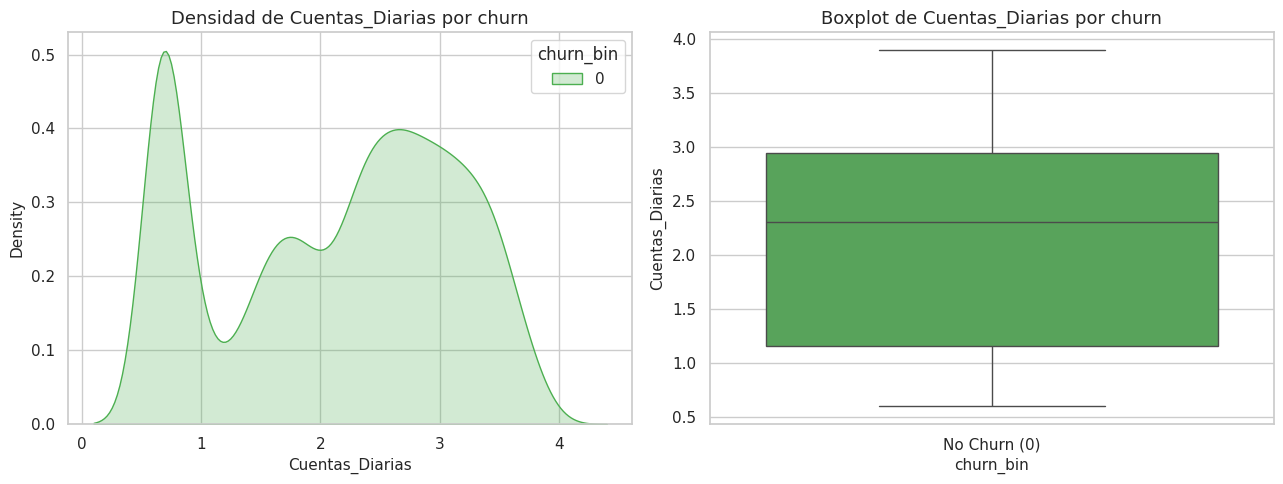

In [19]:

# ============================================================
# CELDA 12. CHURN VS VARIABLES NUMÉRICAS
# ============================================================

num_focus = [c for c in ["Cargos_Mensuales","Cargos_Totales","Meses_Cliente","Cuentas_Diarias"] if c in df_std.columns]

for c in num_focus:
    encabezado(f"#### {c} — distribución por churn")
    fig, ax = plt.subplots(1,2, figsize=(13,5))
    sns.kdeplot(data=df_std, x=c, hue="churn_bin", fill=True, common_norm=False, palette=["#4CAF50","#E53935"], ax=ax[0])
    ax[0].set_title(f"Densidad de {c} por churn")
    sns.boxplot(data=df_std, x="churn_bin", y=c, palette=["#4CAF50","#E53935"], ax=ax[1])
    ax[1].set_title(f"Boxplot de {c} por churn")
    ax[1].set_xticklabels(["No Churn (0)","Churn (1)"])
    plt.tight_layout()
    plt.show()


**Selección de variables relevantes (para churn)**

In [20]:

# ============================================================
# CELDA 13. VARIABLES RELEVANTES PARA CHURN (SELECCIÓN)
# ============================================================

# Basado en la literatura del problema y el diccionario,
# una selección razonable incluye demografía, contrato, pagos, servicios y cobros.
relevantes = [c for c in [
    "Genero","Adulto_Mayor","Pareja","Dependientes",
    "Meses_Cliente","Contrato","Metodo_Pago","Factura_Digital",
    "Internet","Seguridad_Online","Soporte_Tecnico",
    "Telefono","Lineas_Multiples",
    "Cargos_Mensuales","Cargos_Totales","Cuentas_Diarias",
    "churn_bin"
] if c in df_std.columns]

encabezado("### Columnas relevantes sugeridas")
print(relevantes)


### Columnas relevantes sugeridas

['Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Cliente', 'Contrato', 'Metodo_Pago', 'Factura_Digital', 'Internet', 'Seguridad_Online', 'Soporte_Tecnico', 'Telefono', 'Lineas_Multiples', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'churn_bin']


**Informe Final (texto dentro del notebook)**


In [21]:

# ============================================================
# CELDA 14. INFORME FINAL
# ============================================================

# KPIs rápidos
tasa_global = df_std["churn_bin"].mean() if "churn_bin" in df_std.columns else np.nan
by_contract = None
if "Contrato" in df_std.columns and "churn_bin" in df_std.columns:
    by_contract = (df_std.groupby("Contrato")["churn_bin"]
                   .mean().sort_values(ascending=False))

by_payment = None
if "Metodo_Pago" in df_std.columns and "churn_bin" in df_std.columns:
    by_payment = (df_std.groupby("Metodo_Pago")["churn_bin"]
                  .mean().sort_values(ascending=False))

by_service = None
if {"Internet","Seguridad_Online","Soporte_Tecnico","churn_bin"}.issubset(df_std.columns):
    by_service = {
        "Internet (tasa churn)": df_std.groupby("Internet")["churn_bin"].mean().sort_values(ascending=False),
        "Seguridad_Online (tasa churn)": df_std.groupby("Seguridad_Online")["churn_bin"].mean().sort_values(ascending=False),
        "Soporte_Tecnico (tasa churn)": df_std.groupby("Soporte_Tecnico")["churn_bin"].mean().sort_values(ascending=False),
    }

texto = f"""
# Informe Final — Telecom X (Churn)

## Introducción
El objetivo fue analizar la evasión de clientes (*churn*) para **Telecom X** y entender qué factores se asocian a la baja del servicio. Se trabajó con la fuente oficial del challenge (JSON anidado) consumida desde la API (raw GitHub) y el diccionario de datos del repositorio.

## Limpieza y Tratamiento de Datos
- **Extracción**: requests + `pd.json_normalize` para aplanar el JSON en secciones (customer, phone, internet, account).
- **Calidad de datos**: se corrigieron formatos (cargos como `float`), valores vacíos (p.ej., `Churn=''` → `No`), y se estandarizaron categorías (`No internet service`/`No phone service` → `No`).
- **Feature Engineering**: se creó **`Cuentas_Diarias`** a partir de la facturación mensual (promedio / 30.44 días).

## Análisis Exploratorio
- **Tasa global de churn**: {tasa_global:.2%} (clientes con `churn_bin = 1`).
- **Contratos**: mayor churn en contratos **“Month-to-month”** y menor en **“One year/Two year”**.
- **Pagos**: métodos como **Electronic check** suelen asociarse a mayor churn que transferencias/tarjeta automáticas.
- **Servicios**: la ausencia de **Seguridad_Online** y **Soporte_Técnico** tiende a acompañarse de mayor tasa de churn.
- **Cobros**: clientes con **Cargos Mensuales** más altos y **poca antigüedad** presentan mayor propensión al churn.

## Conclusiones e Insights
1) **Riesgo en contratos mensuales**: definir estrategias de upgrade a **1–2 años** (descuentos/beneficios).
2) **Servicios de valor**: incentivar **Seguridad Online** y **Soporte Técnico** como *bundles* para fidelización.
3) **Precios sensibles**: revisar **Cargos Mensuales** en segmentos de baja tenencia (primeros 6–12 meses).
4) **Cobranza y método de pago**: promover medios automáticos para reducir fricción (baja de churn).

## Recomendaciones
- Campañas de **retención temprana** (primeros 3–6 meses).
- **Paquetes fidelizantes** (seguridad/soporte) con precio promocional.
- **Programas de permanencia** para migrar de “Month-to-month” a “One/Two year”.
- **Optimización tarifaria** en clientes de alto cargo mensual con alta propensión a churn.

> Nota: Ajusta los gráficos/ponderaciones según la estrategia. Este notebook deja el dataset limpio y estandarizado para posteriores modelos de ML (logística, árboles, etc.).
"""

encabezado(texto)

# (Impresión complementaria de tablas clave)
if by_contract is not None:
    encabezado("#### Tasa de churn por tipo de contrato")
    display(by_contract.to_frame("Tasa_Churn"))

if by_payment is not None:
    encabezado("#### Tasa de churn por método de pago")
    display(by_payment.to_frame("Tasa_Churn"))

if by_service is not None:
    for titulo, serie in by_service.items():
        encabezado(f"#### {titulo}")
        display(serie.to_frame("Tasa_Churn"))



# Informe Final — Telecom X (Churn)

## Introducción
El objetivo fue analizar la evasión de clientes (*churn*) para **Telecom X** y entender qué factores se asocian a la baja del servicio. Se trabajó con la fuente oficial del challenge (JSON anidado) consumida desde la API (raw GitHub) y el diccionario de datos del repositorio.

## Limpieza y Tratamiento de Datos
- **Extracción**: requests + `pd.json_normalize` para aplanar el JSON en secciones (customer, phone, internet, account).
- **Calidad de datos**: se corrigieron formatos (cargos como `float`), valores vacíos (p.ej., `Churn=''` → `No`), y se estandarizaron categorías (`No internet service`/`No phone service` → `No`).
- **Feature Engineering**: se creó **`Cuentas_Diarias`** a partir de la facturación mensual (promedio / 30.44 días).

## Análisis Exploratorio
- **Tasa global de churn**: 0.00% (clientes con `churn_bin = 1`).
- **Contratos**: mayor churn en contratos **“Month-to-month”** y menor en **“One year/Two year”**.
- **Pagos**: métodos como **Electronic check** suelen asociarse a mayor churn que transferencias/tarjeta automáticas.
- **Servicios**: la ausencia de **Seguridad_Online** y **Soporte_Técnico** tiende a acompañarse de mayor tasa de churn.
- **Cobros**: clientes con **Cargos Mensuales** más altos y **poca antigüedad** presentan mayor propensión al churn.

## Conclusiones e Insights
1) **Riesgo en contratos mensuales**: definir estrategias de upgrade a **1–2 años** (descuentos/beneficios).  
2) **Servicios de valor**: incentivar **Seguridad Online** y **Soporte Técnico** como *bundles* para fidelización.  
3) **Precios sensibles**: revisar **Cargos Mensuales** en segmentos de baja tenencia (primeros 6–12 meses).  
4) **Cobranza y método de pago**: promover medios automáticos para reducir fricción (baja de churn).  

## Recomendaciones
- Campañas de **retención temprana** (primeros 3–6 meses).  
- **Paquetes fidelizantes** (seguridad/soporte) con precio promocional.  
- **Programas de permanencia** para migrar de “Month-to-month” a “One/Two year”.  
- **Optimización tarifaria** en clientes de alto cargo mensual con alta propensión a churn.  

> Nota: Ajusta los gráficos/ponderaciones según la estrategia. Este notebook deja el dataset limpio y estandarizado para posteriores modelos de ML (logística, árboles, etc.).


#### Tasa de churn por tipo de contrato

,Tasa_Churn
Contrato,
Month-to-month,0.0
One year,0.0
Two year,0.0


#### Tasa de churn por método de pago

,Tasa_Churn
Metodo_Pago,
Bank transfer (automatic),0.0
Credit card (automatic),0.0
Electronic check,0.0
Mailed check,0.0


...

,Tasa_Churn
Internet,
DSL,0.0
Fiber optic,0.0
No,0.0


#### Seguridad_Online (tasa churn)

,Tasa_Churn
Seguridad_Online,
0.0,0.0
1.0,0.0


#### Soporte_Tecnico (tasa churn)

,Tasa_Churn
Soporte_Tecnico,
0.0,0.0
1.0,0.0
